In [1]:
import pandas as pd
df = pd.read_csv('/content/train.csv', on_bad_lines='skip')
display(df.head())

,Date,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid,State
0,2022-04-07 04:00:00,77.672528,41.543816,96.779378,13.742698,6.109274362247969,10.158775478404602,7.954523,0.9585691033978502,31.989589,17.664792,Good
1,2024-07-22 12:00:00,NaN,36.545934,98.676911,17.678357,3.6658128446536162,8.821323677464076,6.009300,1.014265519957343,30.408834,13.298733,Good
2,2024-09-01 21:00:00,77.422421,38.070106,90.231446,22.164680,5.9182451718259195,9.885152764032014,7.469829,0.8131948084526466,NaN,14.733992,Good
3,2024-11-10 02:00:00,78.997594,37.579813,111.637115,27.162063,4.185545579392276,10.949836583245743,7.215539,0.9518354570045002,37.745653,26.634651,Bad
4,2022-04-22 00:00:00,77.316031,43.564591,98.552621,11.205911,6.105541368979567,11.376708701973001,7.322156,0.801247182077592,NaN,16.789158,Good


In [2]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types of columns:")
print(df.dtypes)

Missing values per column:
Date        3710
Temp        3623
Visc        3646
Pres        3685
Metal       3644
Water       3444
Additive    3669
pH          3599
Dens        3532
Cond        3578
Oxid        3674
State          4
dtype: int64

Data types of columns:
Date         object
Temp        float64
Visc        float64
Pres        float64
Metal       float64
Water        object
Additive     object
pH          float64
Dens         object
Cond        float64
Oxid        float64
State        object
dtype: object


### Handling Missing Numerical Values

I will fill the missing values in numerical columns with the median of each column. The median is chosen over the mean because it is more robust to outliers in the data.

In [3]:
# Identify numerical columns that are not 'Date'
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Fill missing values in numerical columns with the median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Verify that there are no more missing values in numerical columns
print("\nMissing values after median imputation:")
print(df[numerical_cols].isnull().sum())

Filled missing values in 'Temp' with median: 75.00578855012378
Filled missing values in 'Visc' with median: 40.01326345969016
Filled missing values in 'Pres' with median: 100.03159756634908
Filled missing values in 'Metal' with median: 20.044260963535105
Filled missing values in 'pH' with median: 6.997067580926016
Filled missing values in 'Cond' with median: 29.926766204970992
Filled missing values in 'Oxid' with median: 14.958167155882002

Missing values after median imputation:
Temp     0
Visc     0
Pres     0
Metal    0
pH       0
Cond     0
Oxid     0
dtype: int64


### Outlier Detection using Box Plots

I will use box plots to visualize the distribution of each numerical column and identify potential outliers. Outliers can skew statistical analysis and model training, so understanding their presence is important.

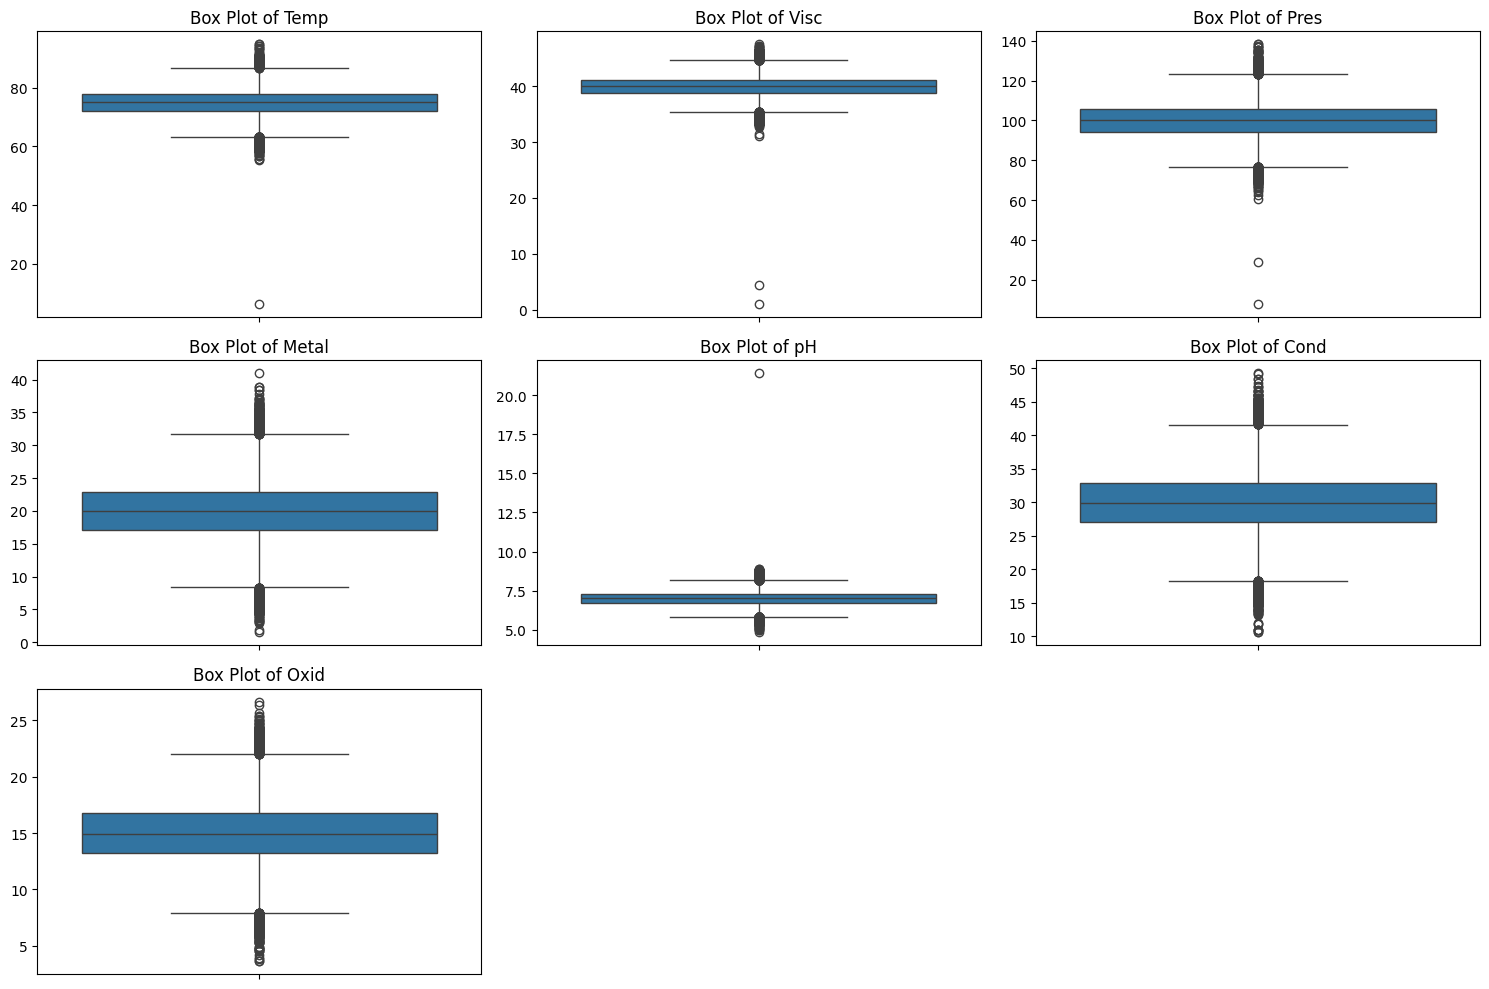

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns (excluding 'Date' which was identified as object type earlier)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Create box plots for numerical columns to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

The box plots above show the distribution of each numerical feature. Any points extending beyond the 'whiskers' of the box plot are considered potential outliers. Based on these visualizations, we can decide on a strategy to handle them, such as winsorization, removal, or transformation.

In [5]:
print(df['State'].unique())

['Good' 'Bad' nan]


In [6]:
df = df.drop(columns=['Date'])
display(df.head())

,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid,State
0,77.672528,41.543816,96.779378,13.742698,6.109274362247969,10.158775478404602,7.954523,0.9585691033978502,31.989589,17.664792,Good
1,75.005789,36.545934,98.676911,17.678357,3.6658128446536162,8.821323677464076,6.009300,1.014265519957343,30.408834,13.298733,Good
2,77.422421,38.070106,90.231446,22.164680,5.9182451718259195,9.885152764032014,7.469829,0.8131948084526466,29.926766,14.733992,Good
3,78.997594,37.579813,111.637115,27.162063,4.185545579392276,10.949836583245743,7.215539,0.9518354570045002,37.745653,26.634651,Bad
4,77.316031,43.564591,98.552621,11.205911,6.105541368979567,11.376708701973001,7.322156,0.801247182077592,29.926766,16.789158,Good


In [7]:
# Check for missing values in the entire DataFrame
missing_values = df.isnull().sum()
print("Missing values per column after all previous operations:")
print(missing_values)

total_missing = missing_values.sum()
print(f"\nTotal number of missing values in the DataFrame: {total_missing}")

Missing values per column after all previous operations:
Temp           0
Visc           0
Pres           0
Metal          0
Water       3444
Additive    3669
pH             0
Dens        3532
Cond           0
Oxid           0
State          4
dtype: int64

Total number of missing values in the DataFrame: 10649


In [8]:
null_state_rows = df[df['State'].isnull()].index.tolist()
print(f"Row numbers with null values in 'State' column: {null_state_rows}")

Row numbers with null values in 'State' column: [11051, 22138, 29523, 35064]


In [9]:
print(df['State'].value_counts(dropna=False))

State
Good    28035
Bad      7026
NaN         4
Name: count, dtype: int64


### Handling Missing Values in Object Columns ('Water', 'Additive', 'Dens') and Encoding 'State'

First, I will attempt to convert the 'Water', 'Additive', and 'Dens' columns to a numeric type. Any values that cannot be converted will be turned into `NaN`. Then, I will fill these (and any original) `NaN`s with the median of each column, similar to how other numerical columns were handled. Finally, the 'State' column will be encoded to numerical values (Good=1, Bad=0), and any rows with `NaN` in 'State' will be dropped.

In [10]:
# Columns to convert to numeric and then impute with median
object_numeric_cols = ['Water', 'Additive', 'Dens']

for col in object_numeric_cols:
    # Convert to numeric, coercing errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fill missing values (original NaNs and those from coercion) with median
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Converted '{col}' to numeric and filled missing values with median: {median_val}")

# Verify data types and missing values for these columns
print("\nData types after conversion and imputation:")
print(df[object_numeric_cols].dtypes)
print("\nMissing values after conversion and imputation:")
print(df[object_numeric_cols].isnull().sum())

Converted 'Water' to numeric and filled missing values with median: 4.991326246853448
Converted 'Additive' to numeric and filled missing values with median: 9.986826997616228
Converted 'Dens' to numeric and filled missing values with median: 0.9007242779896912

Data types after conversion and imputation:
Water       float64
Additive    float64
Dens        float64
dtype: object

Missing values after conversion and imputation:
Water       0
Additive    0
Dens        0
dtype: int64


In [11]:
# Encode 'State' column: 'Good' to 1, 'Bad' to 0
df['State'] = df['State'].map({'Good': 1, 'Bad': 0})

# Drop rows where 'State' is still NaN
before_drop = df.shape[0]
df.dropna(subset=['State'], inplace=True)
after_drop = df.shape[0]
print(f"Dropped {before_drop - after_drop} rows with missing 'State' values.")

# Verify 'State' unique values and missing values
print("\nUnique values in 'State' after encoding and dropping NaNs:")
print(df['State'].unique())
print("\nMissing values in 'State' after operations:")
print(df['State'].isnull().sum())

Dropped 4 rows with missing 'State' values.

Unique values in 'State' after encoding and dropping NaNs:
[1. 0.]

Missing values in 'State' after operations:
0


In [12]:
# Final check for any remaining missing values in the entire DataFrame
final_missing_values = df.isnull().sum()
print("\nFinal missing values per column in the DataFrame:")
print(final_missing_values)

total_final_missing = final_missing_values.sum()
print(f"\nTotal final number of missing values in the DataFrame: {total_final_missing}")

display(df.head())


Final missing values per column in the DataFrame:
Temp        0
Visc        0
Pres        0
Metal       0
Water       0
Additive    0
pH          0
Dens        0
Cond        0
Oxid        0
State       0
dtype: int64

Total final number of missing values in the DataFrame: 0


,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid,State
0,77.672528,41.543816,96.779378,13.742698,6.109274,10.158775,7.954523,0.958569,31.989589,17.664792,1.0
1,75.005789,36.545934,98.676911,17.678357,3.665813,8.821324,6.009300,1.014266,30.408834,13.298733,1.0
2,77.422421,38.070106,90.231446,22.164680,5.918245,9.885153,7.469829,0.813195,29.926766,14.733992,1.0
3,78.997594,37.579813,111.637115,27.162063,4.185546,10.949837,7.215539,0.951835,37.745653,26.634651,0.0
4,77.316031,43.564591,98.552621,11.205911,6.105541,11.376709,7.322156,0.801247,29.926766,16.789158,1.0


### One-Hot Encoding the 'State' Column

As requested, I will now apply one-hot encoding to the 'State' column. Since the 'State' column currently contains only binary values (0.0 for 'Bad' and 1.0 for 'Good'), one-hot encoding will create two new columns (e.g., 'State_0.0' and 'State_1.0'). One column will have a 1 where the original 'State' was 0, and the other will have a 1 where the original 'State' was 1.

In [13]:
# Perform one-hot encoding on the 'State' column
df_encoded = pd.get_dummies(df, columns=['State'], prefix='State', dtype=int)

display(df_encoded.head())

,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid,State_0.0,State_1.0
0,77.672528,41.543816,96.779378,13.742698,6.109274,10.158775,7.954523,0.958569,31.989589,17.664792,0,1
1,75.005789,36.545934,98.676911,17.678357,3.665813,8.821324,6.009300,1.014266,30.408834,13.298733,0,1
2,77.422421,38.070106,90.231446,22.164680,5.918245,9.885153,7.469829,0.813195,29.926766,14.733992,0,1
3,78.997594,37.579813,111.637115,27.162063,4.185546,10.949837,7.215539,0.951835,37.745653,26.634651,1,0
4,77.316031,43.564591,98.552621,11.205911,6.105541,11.376709,7.322156,0.801247,29.926766,16.789158,0,1


### Feature Correlation Matrix

Let's examine the correlation between the different features in the dataset. A correlation matrix helps to identify linear relationships between variables, which can be useful for feature selection and understanding the data structure.

In [14]:
# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid,State_0.0,State_1.0
Temp,1.000000,-0.005871,0.006918,0.004910,-0.000198,0.011347,0.010390,0.004270,-0.001229,0.005834,0.005640,-0.005640
Visc,-0.005871,1.000000,0.009732,-0.011726,-0.004614,-0.005818,-0.001424,0.008224,-0.005367,-0.000458,0.002741,-0.002741
Pres,0.006918,0.009732,1.000000,-0.005611,0.003695,0.003218,-0.004800,-0.001862,-0.002160,0.009133,0.001898,-0.001898
Metal,0.004910,-0.011726,-0.005611,1.000000,-0.010385,0.008170,-0.003605,-0.002715,0.008395,0.003749,-0.006259,0.006259
Water,-0.000198,-0.004614,0.003695,-0.010385,1.000000,-0.008011,0.002268,-0.006168,-0.011713,-0.010408,-0.012411,0.012411
Additive,0.011347,-0.005818,0.003218,0.008170,-0.008011,1.000000,-0.009969,-0.015916,0.008597,0.005514,0.005100,-0.005100
pH,0.010390,-0.001424,-0.004800,-0.003605,0.002268,-0.009969,1.000000,0.009024,0.001947,-0.006393,-0.007034,0.007034
Dens,0.004270,0.008224,-0.001862,-0.002715,-0.006168,-0.015916,0.009024,1.000000,0.010607,0.007129,0.006275,-0.006275
Cond,-0.001229,-0.005367,-0.002160,0.008395,-0.011713,0.008597,0.001947,0.010607,1.000000,0.021098,-0.003457,0.003457
Oxid,0.005834,-0.000458,0.009133,0.003749,-0.010408,0.005514,-0.006393,0.007129,0.021098,1.000000,-0.008063,0.008063


In [15]:
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid,State_0.0,State_1.0
Temp,1.000000,-0.005871,0.006918,0.004910,-0.000198,0.011347,0.010390,0.004270,-0.001229,0.005834,0.005640,-0.005640
Visc,-0.005871,1.000000,0.009732,-0.011726,-0.004614,-0.005818,-0.001424,0.008224,-0.005367,-0.000458,0.002741,-0.002741
Pres,0.006918,0.009732,1.000000,-0.005611,0.003695,0.003218,-0.004800,-0.001862,-0.002160,0.009133,0.001898,-0.001898
Metal,0.004910,-0.011726,-0.005611,1.000000,-0.010385,0.008170,-0.003605,-0.002715,0.008395,0.003749,-0.006259,0.006259
Water,-0.000198,-0.004614,0.003695,-0.010385,1.000000,-0.008011,0.002268,-0.006168,-0.011713,-0.010408,-0.012411,0.012411
Additive,0.011347,-0.005818,0.003218,0.008170,-0.008011,1.000000,-0.009969,-0.015916,0.008597,0.005514,0.005100,-0.005100
pH,0.010390,-0.001424,-0.004800,-0.003605,0.002268,-0.009969,1.000000,0.009024,0.001947,-0.006393,-0.007034,0.007034
Dens,0.004270,0.008224,-0.001862,-0.002715,-0.006168,-0.015916,0.009024,1.000000,0.010607,0.007129,0.006275,-0.006275
Cond,-0.001229,-0.005367,-0.002160,0.008395,-0.011713,0.008597,0.001947,0.010607,1.000000,0.021098,-0.003457,0.003457
Oxid,0.005834,-0.000458,0.009133,0.003749,-0.010408,0.005514,-0.006393,0.007129,0.021098,1.000000,-0.008063,0.008063


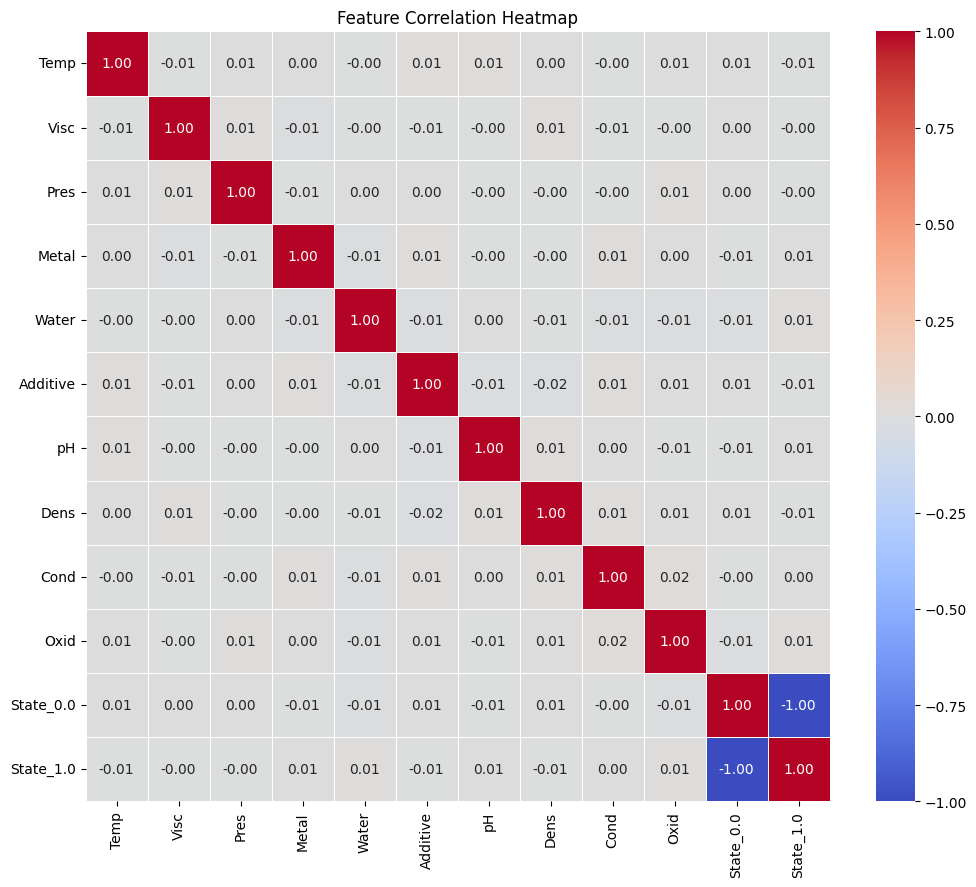

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [17]:
# Check the value counts for the 'State' column to assess imbalance
print("Value counts for the 'State' column:")
print(df['State'].value_counts())

# Calculate the percentage of each class for a clearer view of imbalance
print("\nPercentage of each class in 'State' column:")
print(df['State'].value_counts(normalize=True) * 100)

Value counts for the 'State' column:
State
1.0    28035
0.0     7026
Name: count, dtype: int64

Percentage of each class in 'State' column:
State
1.0    79.96064
0.0    20.03936
Name: proportion, dtype: float64


### Addressing Imbalanced Data with SMOTE

As observed, our dataset is imbalanced, with the 'Good' state (1.0) significantly outnumbering the 'Bad' state (0.0). To mitigate this, we will employ the Synthetic Minority Over-sampling Technique (SMOTE).

SMOTE works by creating synthetic samples of the minority class. It does this by taking samples from the minority class, and for each sample, finding its k-nearest neighbors. Synthetic samples are then generated along the line segments joining the sample and its neighbors. This helps to increase the number of instances in the minority class, leading to a more balanced dataset without simply duplicating existing data points, thereby reducing the risk of overfitting.

After applying SMOTE, we will verify the new distribution of the 'State' column to confirm that the dataset is now balanced.

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('State', axis=1)
y = df['State']

print("Original class distribution:")
print(y.value_counts())

Original class distribution:
State
1.0    28035
0.0     7026
Name: count, dtype: int64


In [19]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nClass distribution after SMOTE:")
print(y_resampled.value_counts())


Class distribution after SMOTE:
State
1.0    28035
0.0    28035
Name: count, dtype: int64


As you can see, after applying SMOTE, both classes in the `State` column now have an equal number of samples, effectively balancing the dataset. `X_resampled` and `y_resampled` contain the newly balanced data that can be used for training machine learning models.

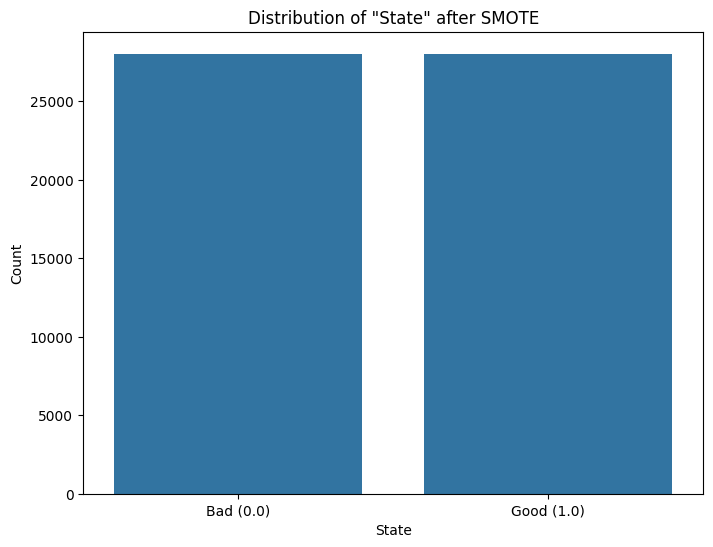

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Distribution of "State" after SMOTE')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks([0, 1], ['Bad (0.0)', 'Good (1.0)'])
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and validation sets (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_resampled,
                                                    y_resampled,
                                                    test_size=0.2, # 20% for validation
                                                    random_state=42, # for reproducibility
                                                    stratify=y_resampled) # maintain class balance

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_val:")
print(y_val.value_counts(normalize=True))

Shape of X_train: (44856, 10)
Shape of X_val: (11214, 10)
Shape of y_train: (44856,)
Shape of y_val: (11214,)

Class distribution in y_train:
State
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Class distribution in y_val:
State
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


In [22]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

def train_evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    print(f"\n--- Training and evaluating {model_name} ---")

    # Train the model
    model.fit(X_train, y_train)

    # Predictions on training set
    y_train_pred = model.predict(X_train)
    print(f"\nClassification Report for {model_name} (Training Set):")
    print(classification_report(y_train, y_train_pred))

    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    print(f"\nClassification Report for {model_name} (Validation Set):")
    print(classification_report(y_val, y_val_pred))

# 1. XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
train_evaluate_model(xgb_model, X_train, y_train, X_val, y_val, "XGBoost")

# 2. LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42)
train_evaluate_model(lgbm_model, X_train, y_train, X_val, y_val, "LightGBM")

# 3. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
train_evaluate_model(rf_model, X_train, y_train, X_val, y_val, "Random Forest")


--- Training and evaluating XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:34:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report for XGBoost (Training Set):
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87     22428
         1.0       0.89      0.85      0.87     22428

    accuracy                           0.87     44856
   macro avg       0.87      0.87      0.87     44856
weighted avg       0.87      0.87      0.87     44856


Classification Report for XGBoost (Validation Set):
              precision    recall  f1-score   support

         0.0       0.77      0.81      0.79      5607
         1.0       0.80      0.76      0.78      5607

    accuracy                           0.79     11214
   macro avg       0.79      0.79      0.79     11214
weighted avg       0.79      0.79      0.79     11214


--- Training and evaluating LightGBM ---
[LightGBM] [Info] Number of positive: 22428, number of negative: 22428
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004746 seconds.
You can set `force_col_wi

### Feature Selection using RandomForestClassifier

In [ ]:
from sklearn.feature_selection import SelectFromModel

# Initialize a RandomForestClassifier (using the best performing model from previous step)
feature_selector = RandomForestClassifier(random_state=42)

# Fit on the resampled training data to find important features
feature_selector.fit(X_resampled, y_resampled)

# Select features based on importance (e.g., features with importance > mean importance)
model_selector = SelectFromModel(feature_selector, prefit=True)

X_train_reduced = model_selector.transform(X_train)
X_val_reduced = model_selector.transform(X_val)

# Get the names of the selected features
selected_features_indices = model_selector.get_support(indices=True)
selected_feature_names = X.columns[selected_features_indices]

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {X_train_reduced.shape[1]}")
print(f"Selected features: {list(selected_feature_names)}")

Original number of features: 10
Reduced number of features: 5
Selected features: ['Temp', 'Visc', 'Pres', 'Water', 'Cond']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


### Retraining Random Forest with Reduced Features

In [ ]:
# Retrain the Random Forest Classifier with reduced features
rf_model_reduced = RandomForestClassifier(random_state=42)
train_evaluate_model(rf_model_reduced, X_train_reduced, y_train, X_val_reduced, y_val, "Random Forest (Reduced Features)")

### Preprocessing Test Data and Generating Submission File

Now, I will load the `test.csv` file and apply the same preprocessing steps as were applied to the training data. Then, I will use the trained Random Forest model to predict the 'State' for the test set and create a submission file.

In [23]:
# Load the test data
df_test = pd.read_csv('/content/test.csv', on_bad_lines='skip')

# Keep track of original index for submission file, assuming 'id' column exists or using index
if 'id' in df_test.columns:
    test_ids = df_test['id']
    df_test = df_test.drop('id', axis=1)
else:
    test_ids = df_test.index # Use DataFrame index as IDs if no 'id' column

display(df_test.head())

,Date,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid
0,2022-01-01 09:00:00,77.712800,39.475586,NaN,6.384677,3.528095,8.810304,NaN,0.839482,29.622919,18.369457
1,2022-01-01 11:00:00,72.671351,NaN,80.397663,NaN,4.612895,10.952341,6.145431,0.842191,35.867533,9.955919
2,2022-01-01 13:00:00,65.433599,39.194120,103.153349,18.833237,4.447228,9.507234,6.958221,0.946828,NaN,13.516650
3,2022-01-01 16:00:00,69.935844,37.254642,101.467905,22.445447,6.414117,8.943044,6.701323,1.018445,37.197921,14.309967
4,2022-01-02 00:00:00,72.278086,42.194466,103.104813,17.863880,3.865240,12.305562,7.310154,0.838131,NaN,14.229487


In [24]:
# Drop the 'Date' column from test data
if 'Date' in df_test.columns:
    df_test = df_test.drop(columns=['Date'])
    print("Dropped 'Date' column from test data.")

print("\nMissing values in test data before imputation:")
print(df_test.isnull().sum())

Dropped 'Date' column from test data.

Missing values in test data before imputation:
Temp        611
Visc        645
Pres        667
Metal       661
Water       617
Additive    611
pH          598
Dens        618
Cond        635
Oxid        632
dtype: int64


In [25]:
# Identify numerical columns in test data
numerical_cols_test = df_test.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Fill missing values in numerical columns with the median (re-calculating for test set)
for col in numerical_cols_test:
    if df_test[col].isnull().any():
        median_val_test = df_test[col].median()
        df_test[col] = df_test[col].fillna(median_val_test)
        print(f"Filled missing values in test '{col}' with median: {median_val_test}")

# Columns to convert to numeric and then impute with median for test data
object_numeric_cols_test = ['Water', 'Additive', 'Dens'] # Assuming these columns exist in test set

for col in object_numeric_cols_test:
    if col in df_test.columns:
        df_test[col] = pd.to_numeric(df_test[col], errors='coerce')
        if df_test[col].isnull().any():
            median_val_test = df_test[col].median()
            df_test[col] = df_test[col].fillna(median_val_test)
            print(f"Converted test '{col}' to numeric and filled missing values with median: {median_val_test}")

# Verify no missing values in the preprocessed test data
print("\nMissing values in test data after imputation:")
print(df_test.isnull().sum().sum())

# Ensure the test data has the same columns as X_train
# This assumes the original df used to create X_train had 10 features besides 'State'
# Drop any extra columns from df_test that were not in X_train
extra_cols = set(df_test.columns) - set(X_train.columns)
if extra_cols:
    df_test = df_test.drop(columns=list(extra_cols))
    print(f"Dropped extra columns from test data: {list(extra_cols)}")

# Add any missing columns to df_test that were in X_train, filling with 0 (or appropriate default)
missing_cols = set(X_train.columns) - set(df_test.columns)
for col in missing_cols:
    df_test[col] = 0 # Or some other appropriate default value like median/mean of training data for that column
    print(f"Added missing column to test data: {col}")

# Reorder columns to match X_train
df_test = df_test[X_train.columns]

display(df_test.head())

Filled missing values in test 'Temp' with median: 75.07254499631327
Filled missing values in test 'Visc' with median: 39.99228020945814
Filled missing values in test 'Pres' with median: 100.0368649104504
Filled missing values in test 'Metal' with median: 19.96840538640337
Filled missing values in test 'Water' with median: 5.032415997790936
Filled missing values in test 'Additive' with median: 9.979010817465111
Filled missing values in test 'pH' with median: 6.99861254020428
Filled missing values in test 'Dens' with median: 0.8996039361070408
Filled missing values in test 'Cond' with median: 30.048389579089267
Filled missing values in test 'Oxid' with median: 15.007878803723148

Missing values in test data after imputation:
0


,Temp,Visc,Pres,Metal,Water,Additive,pH,Dens,Cond,Oxid
0,77.712800,39.475586,100.036865,6.384677,3.528095,8.810304,6.998613,0.839482,29.622919,18.369457
1,72.671351,39.992280,80.397663,19.968405,4.612895,10.952341,6.145431,0.842191,35.867533,9.955919
2,65.433599,39.194120,103.153349,18.833237,4.447228,9.507234,6.958221,0.946828,30.048390,13.516650
3,69.935844,37.254642,101.467905,22.445447,6.414117,8.943044,6.701323,1.018445,37.197921,14.309967
4,72.278086,42.194466,103.104813,17.863880,3.865240,12.305562,7.310154,0.838131,30.048390,14.229487


In [28]:
# Apply the XGBoost model to the preprocessed test data
predictions = xgb_model.predict(df_test)

# Convert numerical predictions back to 'Good' and 'Bad' labels
# Assuming 1.0 was 'Good' and 0.0 was 'Bad' from previous encoding
predicted_states = pd.Series(predictions).map({1.0: 'Good', 0.0: 'Bad'})

# Create the submission DataFrame
submission_df = pd.DataFrame({'ID': test_ids + 1, 'State': predicted_states})

# Display the first few rows of the submission file
display(submission_df.head())

# Save the submission file to a CSV
submission_df.to_csv('submission_xgb.csv', index=False)
print("Submission file 'submission_xgb.csv' created successfully!")

,ID,State
0,1,Good
1,2,Good
2,3,Bad
3,4,Good
4,5,Bad


Submission file 'submission_xgb.csv' created successfully!


### Preprocessing Test Data with Reduced Features and Generating Submission File

In [ ]:
# Apply the same feature reduction to the preprocessed test data
df_test_reduced = model_selector.transform(df_test)

# Apply the retrained Random Forest model (with reduced features) to the test data
predictions_reduced = rf_model_reduced.predict(df_test_reduced)

# Convert numerical predictions back to 'Good' and 'Bad' labels
predicted_states_reduced = pd.Series(predictions_reduced).map({1.0: 'Good', 0.0: 'Bad'})

# Create the submission DataFrame
submission_df_reduced = pd.DataFrame({'ID': test_ids + 1, 'State': predicted_states_reduced})

# Display the first few rows of the submission file
display(submission_df_reduced.head())

# Save the submission file to a CSV
submission_df_reduced.to_csv('submission_rf_reduced.csv', index=False)
print("Submission file 'submission_rf_reduced.csv' created successfully!")